In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/samuelotiattakorah/agriculture-crop-yield/crop_yield.csv


In [2]:
#======================================== Import Libraries ========================================#
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.feature_selection import VarianceThreshold,SelectKBest,f_regression,SelectFromModel
from sklearn.model_selection import train_test_split,RandomizedSearchCV,cross_val_score
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor,HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Ignore All Warnings
warnings.filterwarnings('ignore')

In [3]:
#======================================== Load Dataset ========================================#
crop_df = pd.read_csv('/kaggle/input/datasets/samuelotiattakorah/agriculture-crop-yield/crop_yield.csv')

In [4]:
#======================================== Dataset Overview ========================================#
print("#" + "=" * 140 + "#")
display(crop_df.head()) # Preview The Dataset
print("#" + "=" * 140 + "#")
display(crop_df.info()) # About Dataset
print("#" + "=" * 140 + "#")
display(crop_df.describe()) # Stats
print("#" + "=" * 140 + "#")
print("Shape of Dataset: ",crop_df.shape)
print("#" + "=" * 140 + "#")
display(crop_df.select_dtypes(include = ['number']).corr()) # Relation
print("#" + "=" * 140 + "#")
display(crop_df.select_dtypes(include = ['number']).skew()) # Dataset Spread
print("#" + "=" * 140 + "#")
display(crop_df.select_dtypes(include = ['number']).cov()) # Covariance
print("#" + "=" * 140 + "#")

#============================================================================================================================================#


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


#============================================================================================================================================#
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


None

#============================================================================================================================================#


...

#============================================================================================================================================#


Rainfall_mm              -0.000934
Temperature_Celsius      -0.000534
Days_to_Harvest           0.000033
Yield_tons_per_hectare   -0.000862
dtype: float64

#============================================================================================================================================#


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
Rainfall_mm,67522.708650,-0.230794,-18.002492,337.086867
Temperature_Celsius,-0.230794,52.137174,-0.136986,1.048197
Days_to_Harvest,-18.002492,-0.136986,673.579609,-0.114070
Yield_tons_per_hectare,337.086867,1.048197,-0.114070,2.878358


#============================================================================================================================================#


In [5]:
#======================================== Data Cleaning ========================================#
print("#" + "=" * 140 + "#")
display('Null Valuse Present In Dataset: ',crop_df.isnull().mean() * 100)
print("#" + "=" * 140 + "#")
display('Duplicates Valuse Present In Dataset: ',crop_df.duplicated().sum())
print("#" + "=" * 140 + "#")
display('Unique Values Present In Dataset: ',crop_df.nunique())
print("#" + "=" * 140 + "#")
# Convert The All Object Columns In Lower-case
object_columns = crop_df.select_dtypes(include = ['object']).columns
crop_df[object_columns] = crop_df[object_columns].apply(lambda x:x.str.lower())
# Change The DataType of All Object Columns
categorical_columns = crop_df.select_dtypes(include = ['object']).columns
crop_df[categorical_columns] = crop_df[categorical_columns].apply(lambda x:x.astype('category'))
# Change The DataType of Boolean Columns
bool_columns = crop_df.select_dtypes(include = ['bool']).columns
crop_df[bool_columns] = crop_df[bool_columns].replace({True:"true",False:"false"})

#============================================================================================================================================#


'Null Valuse Present In Dataset: '

Region                    0.0
Soil_Type                 0.0
Crop                      0.0
Rainfall_mm               0.0
Temperature_Celsius       0.0
Fertilizer_Used           0.0
Irrigation_Used           0.0
Weather_Condition         0.0
Days_to_Harvest           0.0
Yield_tons_per_hectare    0.0
dtype: float64

#============================================================================================================================================#


'Duplicates Valuse Present In Dataset: '

np.int64(0)

#============================================================================================================================================#


'Unique Values Present In Dataset: '

Region                          4
Soil_Type                       6
Crop                            6
Rainfall_mm               1000000
Temperature_Celsius       1000000
Fertilizer_Used                 2
Irrigation_Used                 2
Weather_Condition               3
Days_to_Harvest                90
Yield_tons_per_hectare    1000000
dtype: int64

#============================================================================================================================================#


In [6]:
bool_columns = crop_df.select_dtypes(include = ['object']).columns
crop_df[bool_columns] = crop_df[bool_columns].apply(lambda x:x.astype('category'))

#==================================================#
Rainfall_mm Has 0 Outliers
#==================================================#


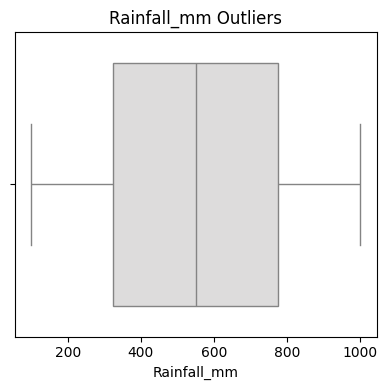

#==================================================#
Temperature_Celsius Has 0 Outliers
#==================================================#


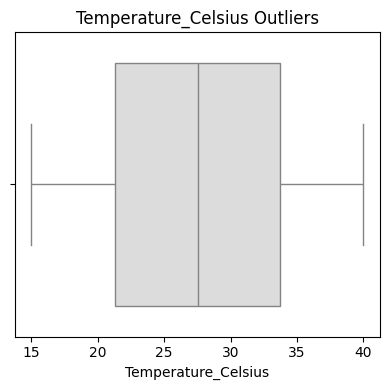

#==================================================#
Days_to_Harvest Has 0 Outliers
#==================================================#


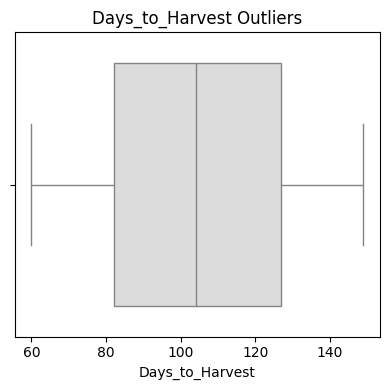

#==================================================#
Yield_tons_per_hectare Has 84 Outliers
#==================================================#


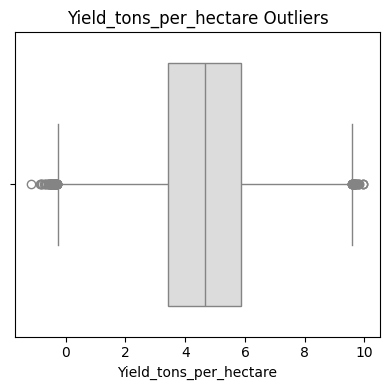

#==================================================#
Total Dataset Percentage Outlier Present In Dataset: 0.01%
#==================================================#
Total Unique Outliers Present In Dataset: 84
#==================================================#


In [7]:
#======================================== Outlier's Detection ========================================#
outlier_data = crop_df.copy()
outlier_box = set()
numeric_columns = crop_df.select_dtypes(include = ['number']).columns
for num_cols in numeric_columns:
    Q1 = outlier_data[num_cols].quantile(0.25)
    Q3 = outlier_data[num_cols].quantile(0.75)
    IQR = Q3 - Q1
    Lower_round = Q1 - 1.5 * IQR
    Upper_round = Q3 + 1.5 * IQR
    Outliers = outlier_data[(outlier_data[num_cols] < Lower_round) | (outlier_data[num_cols] > Upper_round)]
    outlier_box.update(Outliers.index)
    print("#" + "=" * 50 + "#")
    print(f'{num_cols} Has {len(Outliers)} Outliers')
    print("#" + "=" * 50 + "#")
    plt.figure(figsize = (4,4))
    plt.title(f'{num_cols} Outliers')
    sns.boxplot(x = outlier_data[num_cols],palette = 'coolwarm')
    plt.tight_layout()
    plt.show()

result = (len(outlier_box) / len(outlier_data)) * 100
print("#" + "=" * 50 + "#")
print(f'Total Dataset Percentage Outlier Present In Dataset: {result:.2f}%')
print("#" + "=" * 50 + "#")
print(f'Total Unique Outliers Present In Dataset: {len(outlier_box)}')
print("#" + "=" * 50 + "#")

In [8]:
# 
df = crop_df.drop(index = list(outlier_box)).reset_index(drop = True)

#==================================================#
Region
north    250173
west     250074
south    250054
east     249699
Name: count, dtype: int64


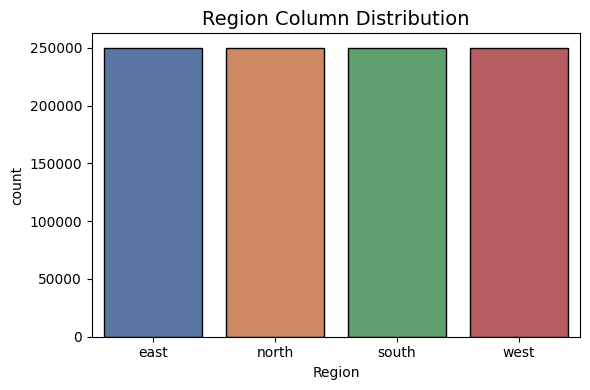

#==================================================#
Soil_Type
sandy     167119
loam      166795
chalky    166779
silt      166672
clay      166352
peaty     166283
Name: count, dtype: int64


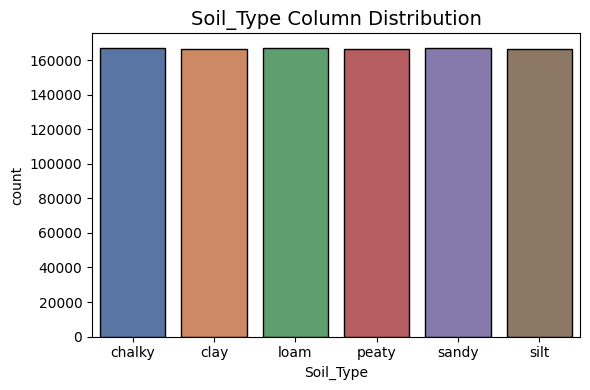

#==================================================#
Crop
maize      166824
rice       166792
barley     166777
wheat      166673
cotton     166585
soybean    166349
Name: count, dtype: int64


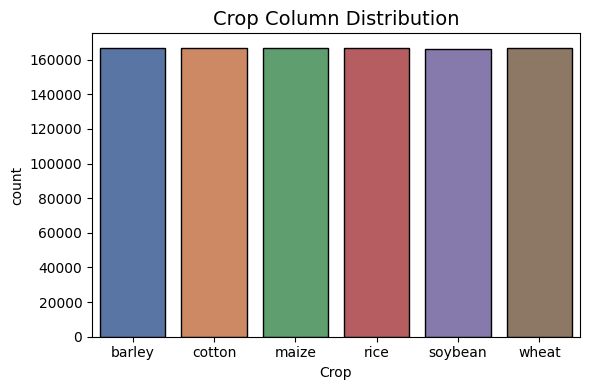

#==================================================#
Fertilizer_Used
false    500060
true     499940
Name: count, dtype: int64


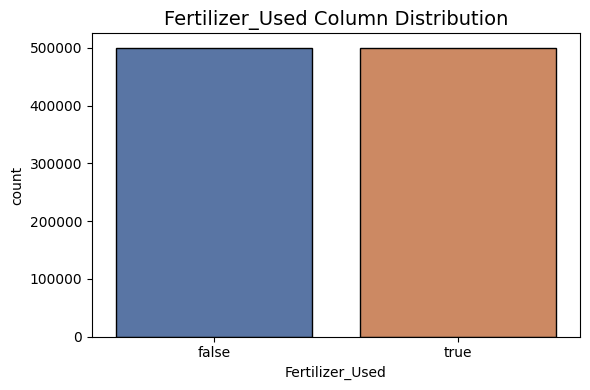

#==================================================#
Irrigation_Used
false    500509
true     499491
Name: count, dtype: int64


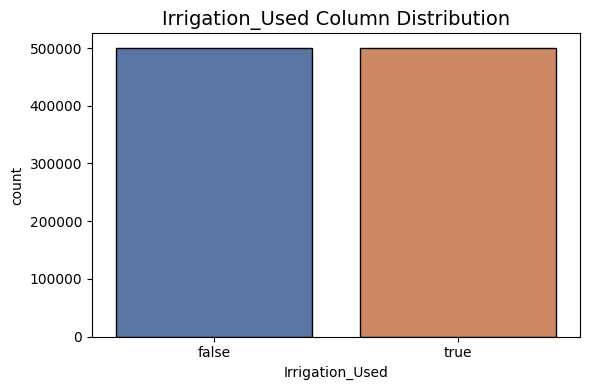

#==================================================#
Weather_Condition
sunny     333790
rainy     333561
cloudy    332649
Name: count, dtype: int64


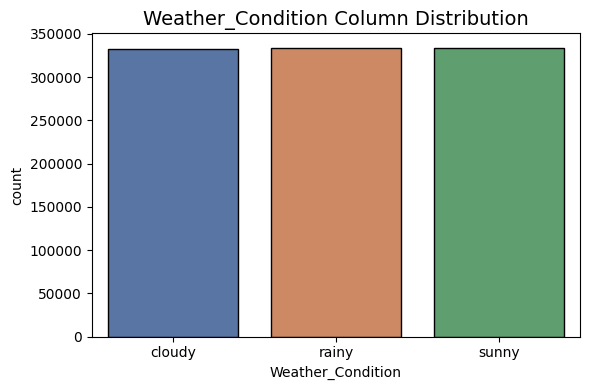

In [9]:
#=========================================== Check All Category Types and Distribution ============================================#
try:
    categorical_columns = crop_df.select_dtypes(include = ['category'])
    for cat_cols in categorical_columns:
        print("#" + "=" * 50 + "#")
        print(crop_df[cat_cols].value_counts())
        plt.figure(figsize = (6,4))
        plt.title(f"{cat_cols} Column Distribution",fontsize = 14)
        sns.countplot(x = crop_df[cat_cols],palette = 'deep',edgecolor = 'black')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Error: {e}")
    

#==================================================#
count    1000000.000000
mean         549.981901
std          259.851320
min          100.000896
25%          324.891090
50%          550.124061
75%          774.738520
max          999.998098
Name: Rainfall_mm, dtype: float64


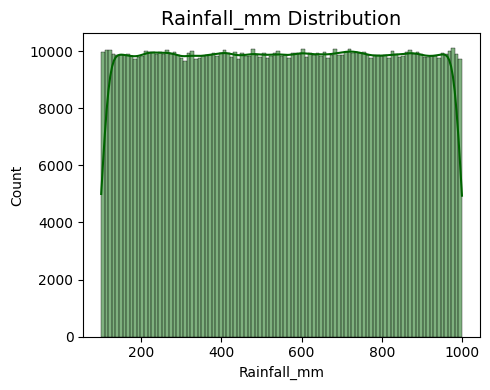

#==================================================#
count    1000000.000000
mean          27.504965
std            7.220608
min           15.000034
25%           21.254502
50%           27.507365
75%           33.753267
max           39.999997
Name: Temperature_Celsius, dtype: float64


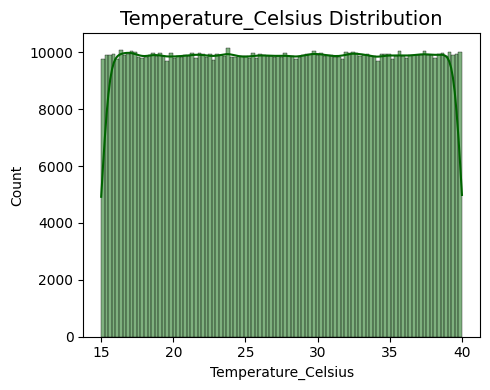

#==================================================#
count    1000000.000000
mean         104.495025
std           25.953412
min           60.000000
25%           82.000000
50%          104.000000
75%          127.000000
max          149.000000
Name: Days_to_Harvest, dtype: float64


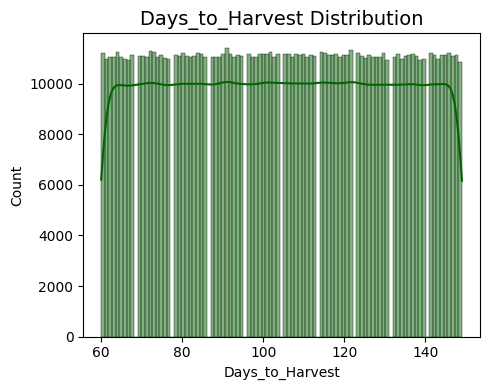

#==================================================#
count    1000000.000000
mean           4.649472
std            1.696572
min           -1.147613
25%            3.417637
50%            4.651808
75%            5.879200
max            9.963372
Name: Yield_tons_per_hectare, dtype: float64


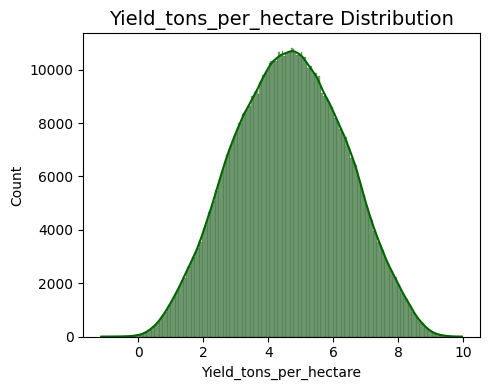

In [10]:
#=========================================== Check All Numerical Distribution ============================================#
try:
    numerical_columns = crop_df.select_dtypes(include = ['number']).columns
    for num_col in numerical_columns:
        print("#" + "=" * 50 + "#")
        print(crop_df[num_col].describe())  
        plt.figure(figsize = (5, 4))       
        plt.title(f"{num_col} Distribution", fontsize = 14)
        sns.histplot(data = crop_df, x = num_col, kde = True, color = 'darkgreen', edgecolor = 'black')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Error: {e}")

#================= Average Rainfall mm =================#


Region,east,north,south,west,All
Soil_Type,,,,,
chalky,550.360223,551.164711,550.453048,552.198351,551.046432
clay,549.870518,549.114083,547.541236,550.658223,549.296881
loam,547.996265,551.428513,550.975419,548.105595,549.630783
peaty,549.353017,552.218904,550.939530,548.649973,550.288238
sandy,548.461687,550.906912,549.764847,549.440613,549.639034
silt,549.433964,549.933118,550.399525,550.193043,549.989932
All,549.243755,550.793416,550.013776,549.875231,549.981901



#================= Minimum Rainfall mm =================#


Region,east,north,south,west,All
Soil_Type,,,,,
chalky,100.014436,100.010397,100.023547,100.012870,100.010397
clay,100.006194,100.006387,100.017174,100.012778,100.006194
loam,100.005771,100.025207,100.037315,100.006823,100.005771
peaty,100.027879,100.044470,100.011774,100.000896,100.000896
sandy,100.035645,100.005750,100.020579,100.083341,100.005750
silt,100.053890,100.013357,100.011989,100.032637,100.011989
All,100.005771,100.005750,100.011774,100.000896,100.000896



#================= Maximum Rainfall mm =================#


Region,east,north,south,west,All
Soil_Type,,,,,
chalky,999.968211,999.977761,999.979793,999.977677,999.979793
clay,999.976757,999.992000,999.987914,999.954481,999.992000
loam,999.983710,999.984840,999.923753,999.997270,999.997270
peaty,999.985356,999.991820,999.915169,999.996596,999.996596
sandy,999.984215,999.975320,999.995204,999.998098,999.998098
silt,999.986494,999.899979,999.996552,999.996116,999.996552
All,999.986494,999.992000,999.996552,999.998098,999.998098


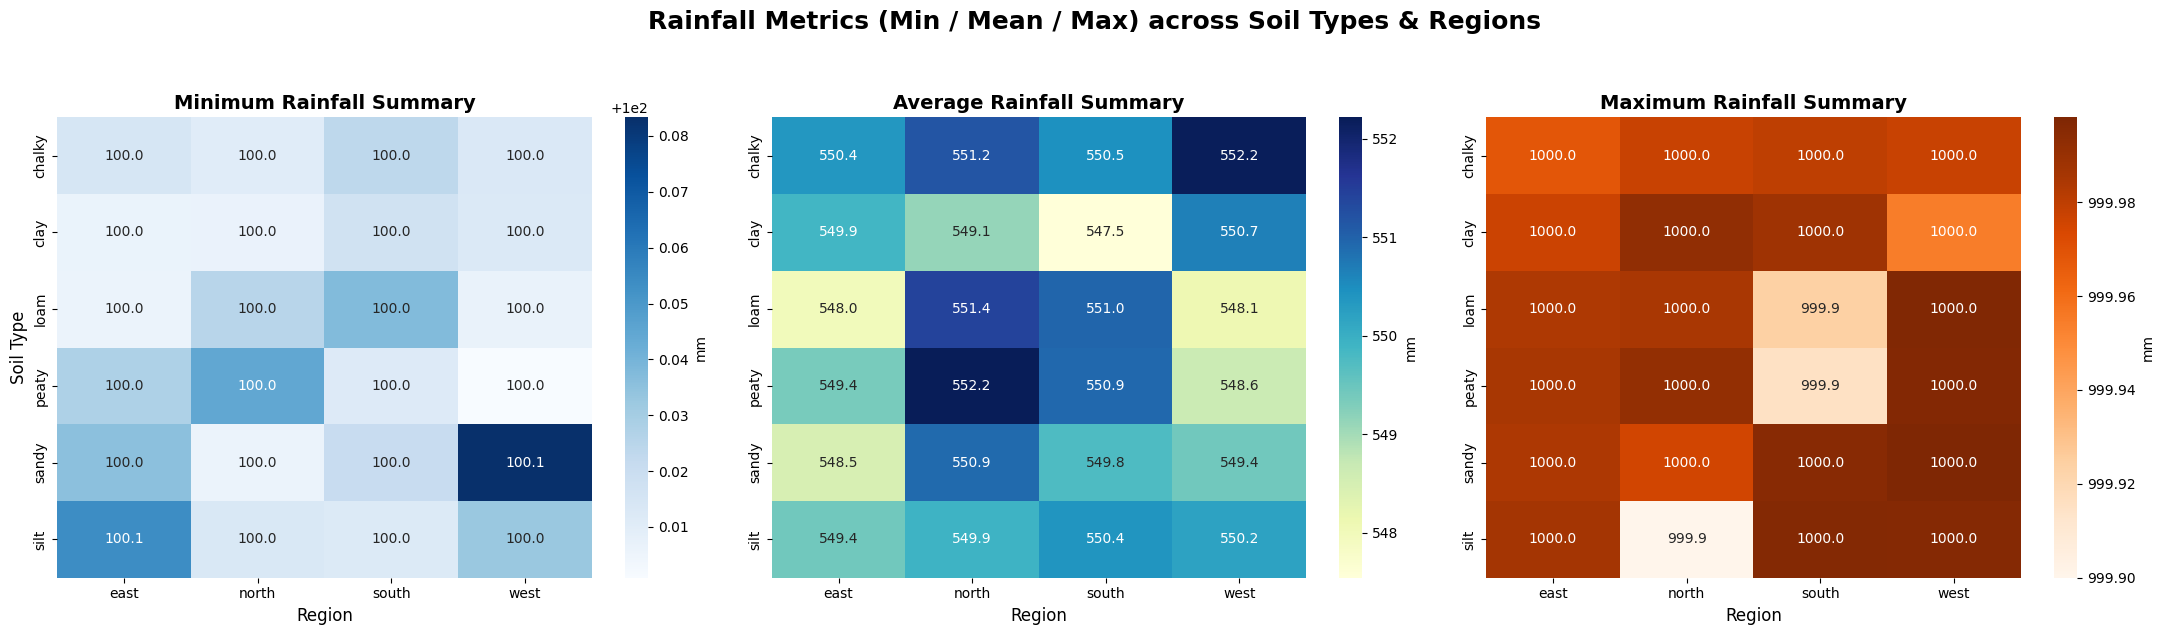

In [11]:
#=========================================== Filtering & Visualizing Dataset ============================================#
try:
    Rainfall_mm_avg_summary = crop_df.pivot_table(index='Soil_Type', columns='Region', values='Rainfall_mm', aggfunc='mean', margins=True)
    Rainfall_mm_min_summary = crop_df.pivot_table(index='Soil_Type', columns='Region', values='Rainfall_mm', aggfunc='min', margins=True)
    Rainfall_mm_max_summary = crop_df.pivot_table(index='Soil_Type', columns='Region', values='Rainfall_mm', aggfunc='max', margins=True)

    print("#================= Average Rainfall mm =================#")
    display(Rainfall_mm_avg_summary)
    print("\n#================= Minimum Rainfall mm =================#")
    display(Rainfall_mm_min_summary)
    print("\n#================= Maximum Rainfall mm =================#")
    display(Rainfall_mm_max_summary)

except Exception as e:
    print(f"Data generation error: {e}")

try:

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.heatmap(data=Rainfall_mm_min_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="Blues", ax=axes[0], cbar_kws={'label': 'mm'})
    axes[0].set_title("Minimum Rainfall Summary", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Region", fontsize=12)
    axes[0].set_ylabel("Soil Type", fontsize=12)

    sns.heatmap(data=Rainfall_mm_avg_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1], cbar_kws={'label': 'mm'})
    axes[1].set_title("Average Rainfall Summary", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Region", fontsize=12)
    axes[1].set_ylabel("") 
    

    sns.heatmap(data=Rainfall_mm_max_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="Oranges", ax=axes[2], cbar_kws={'label': 'mm'})
    axes[2].set_title("Maximum Rainfall Summary", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Region", fontsize=12)
    axes[2].set_ylabel("") 
    
    plt.suptitle("Rainfall Metrics (Min / Mean / Max) across Soil Types & Regions", fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig("Rainfall_Metrics.png")
    plt.show()

except Exception as e:
    print(f"Plotting error: {e}")


#================= Average Temperature_Celsius =================#


Region,east,north,south,west,All
Soil_Type,,,,,
chalky,27.516488,27.497132,27.485638,27.521956,27.505280
clay,27.467683,27.519767,27.478862,27.511455,27.494451
loam,27.441609,27.475045,27.507099,27.493076,27.479273
peaty,27.572190,27.544811,27.515643,27.498480,27.532739
sandy,27.522797,27.478565,27.489607,27.560709,27.512928
silt,27.498381,27.461298,27.539525,27.521705,27.505162
All,27.503226,27.496045,27.502708,27.517882,27.504965



#================= Minimum Temperature_Celsius =================#


Region,east,north,south,west,All
Soil_Type,,,,,
chalky,15.000202,15.000396,15.000034,15.000606,15.000034
clay,15.000408,15.000085,15.000068,15.000697,15.000068
loam,15.001883,15.002291,15.000268,15.000994,15.000268
peaty,15.000229,15.003833,15.000041,15.000617,15.000041
sandy,15.001166,15.000927,15.000126,15.000480,15.000126
silt,15.001078,15.000673,15.000276,15.000293,15.000276
All,15.000202,15.000085,15.000034,15.000293,15.000034



#================= Maximum Temperature_Celsius =================#


Region,east,north,south,west,All
Soil_Type,,,,,
chalky,39.999974,39.997681,39.998806,39.999898,39.999974
clay,39.999436,39.998574,39.998947,39.999601,39.999601
loam,39.998745,39.999997,39.998681,39.999809,39.999997
peaty,39.999596,39.999183,39.999772,39.998866,39.999772
sandy,39.999817,39.999762,39.999932,39.999064,39.999932
silt,39.999727,39.999700,39.999615,39.998782,39.999727
All,39.999974,39.999997,39.999932,39.999898,39.999997


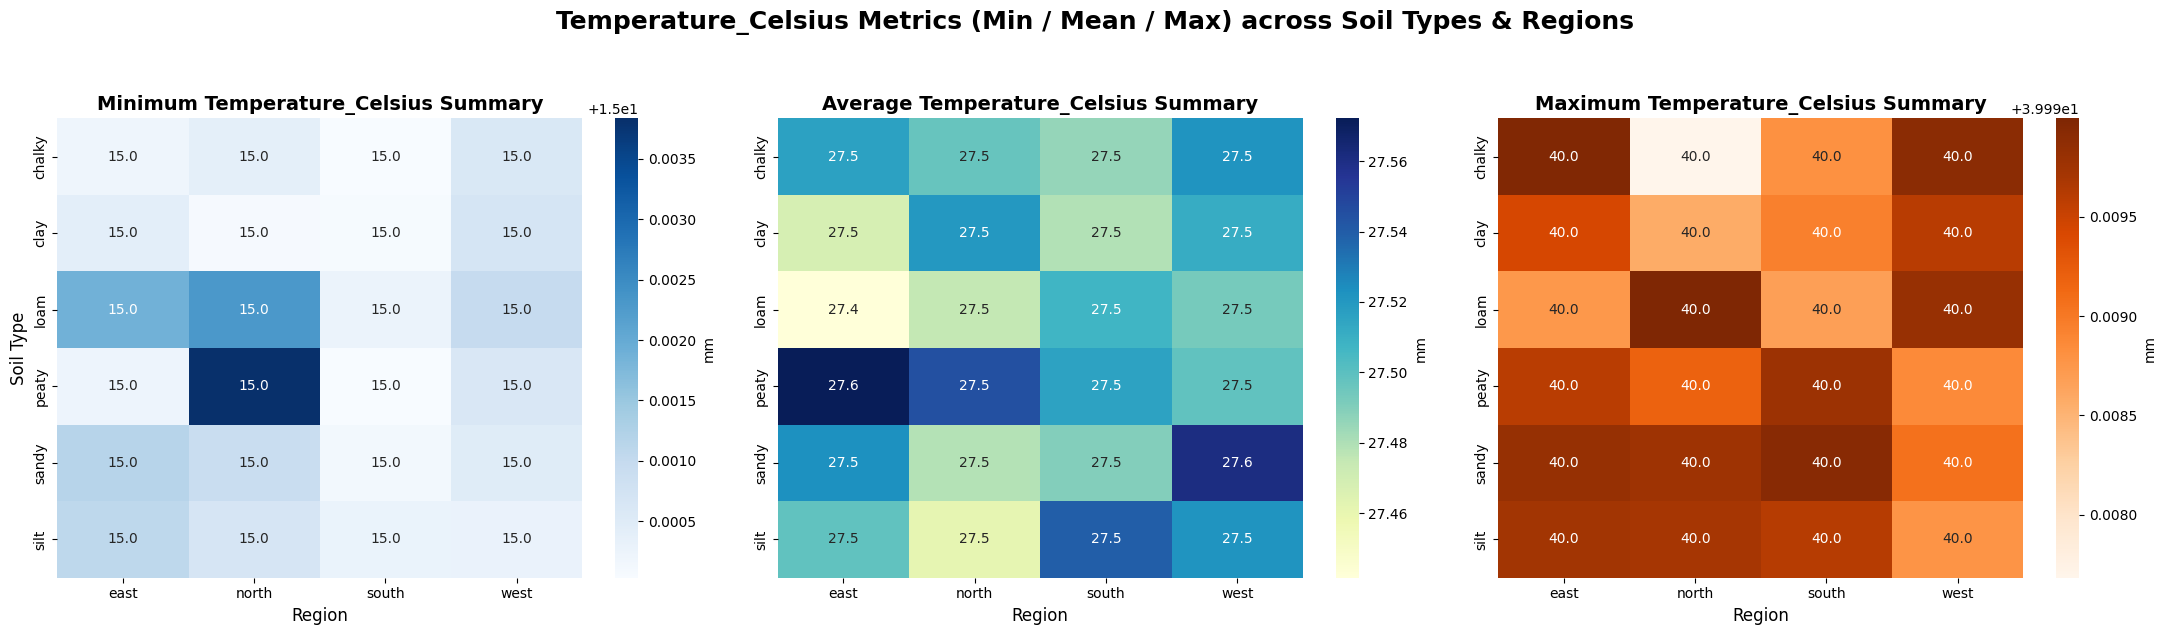

In [12]:
#=========================================== Filtering & Visualizing Dataset ============================================#
try:
    Temperature_Celsius_avg_summary = crop_df.pivot_table(index='Soil_Type', columns='Region', values='Temperature_Celsius', aggfunc='mean', margins=True)
    Temperature_Celsius_min_summary = crop_df.pivot_table(index='Soil_Type', columns='Region', values='Temperature_Celsius', aggfunc='min', margins=True)
    Temperature_Celsius_max_summary = crop_df.pivot_table(index='Soil_Type', columns='Region', values='Temperature_Celsius', aggfunc='max', margins=True)

    print("#================= Average Temperature_Celsius =================#")
    display(Temperature_Celsius_avg_summary)
    print("\n#================= Minimum Temperature_Celsius =================#")
    display(Temperature_Celsius_min_summary)
    print("\n#================= Maximum Temperature_Celsius =================#")
    display(Temperature_Celsius_max_summary)

except Exception as e:
    print(f"Data generation error: {e}")

try:

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.heatmap(data=Temperature_Celsius_min_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="Blues", ax=axes[0], cbar_kws={'label': 'mm'})
    axes[0].set_title("Minimum Temperature_Celsius Summary", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Region", fontsize=12)
    axes[0].set_ylabel("Soil Type", fontsize=12)

    sns.heatmap(data=Temperature_Celsius_avg_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1], cbar_kws={'label': 'mm'})
    axes[1].set_title("Average Temperature_Celsius Summary", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Region", fontsize=12)
    axes[1].set_ylabel("") 
    

    sns.heatmap(data=Temperature_Celsius_max_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="Oranges", ax=axes[2], cbar_kws={'label': 'mm'})
    axes[2].set_title("Maximum Temperature_Celsius Summary", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Region", fontsize=12)
    axes[2].set_ylabel("") 
    
    plt.suptitle("Temperature_Celsius Metrics (Min / Mean / Max) across Soil Types & Regions", fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig("Temperature_Celsius.png")
    plt.show()

except Exception as e:
    print(f"Plotting error: {e}")


#================= Average Yield tons per hectare =================#


Region,east,north,south,west,All
Soil_Type,,,,,
chalky,4.647942,4.651547,4.652636,4.659398,4.652895
clay,4.647960,4.642988,4.633997,4.654600,4.644891
loam,4.642070,4.663495,4.654845,4.643720,4.651056
peaty,4.647270,4.662935,4.660141,4.633988,4.651063
sandy,4.638744,4.657796,4.639906,4.657819,4.648511
silt,4.649677,4.645990,4.651540,4.646471,4.648414
All,4.645594,4.654114,4.648843,4.649331,4.649472



#================= Minimum Yield tons per hectare =================#


Region,east,north,south,west,All
Soil_Type,,,,,
chalky,-0.516340,-0.475287,-0.466695,-0.875193,-0.875193
clay,-0.802800,-1.147613,-0.471038,-0.699819,-1.147613
loam,-0.543567,-0.405764,-0.568767,-0.731541,-0.731541
peaty,-0.468290,-0.563558,-0.573014,-0.645920,-0.645920
sandy,-0.404635,-0.496933,-0.147401,-0.841617,-0.841617
silt,-0.559459,-0.309650,-0.818945,-0.352921,-0.818945
All,-0.802800,-1.147613,-0.818945,-0.875193,-1.147613



#================= Maximum Yield tons per hectare =================#


Region,east,north,south,west,All
Soil_Type,,,,,
chalky,9.562447,9.949207,9.963372,9.769839,9.963372
clay,9.721110,9.466969,9.617817,9.595395,9.721110
loam,9.744646,9.647672,9.435684,9.952983,9.952983
peaty,9.516268,9.559016,9.527448,9.727004,9.727004
sandy,9.802534,9.786272,9.548654,9.588945,9.802534
silt,9.431513,9.526382,9.826285,9.580166,9.826285
All,9.802534,9.949207,9.963372,9.952983,9.963372


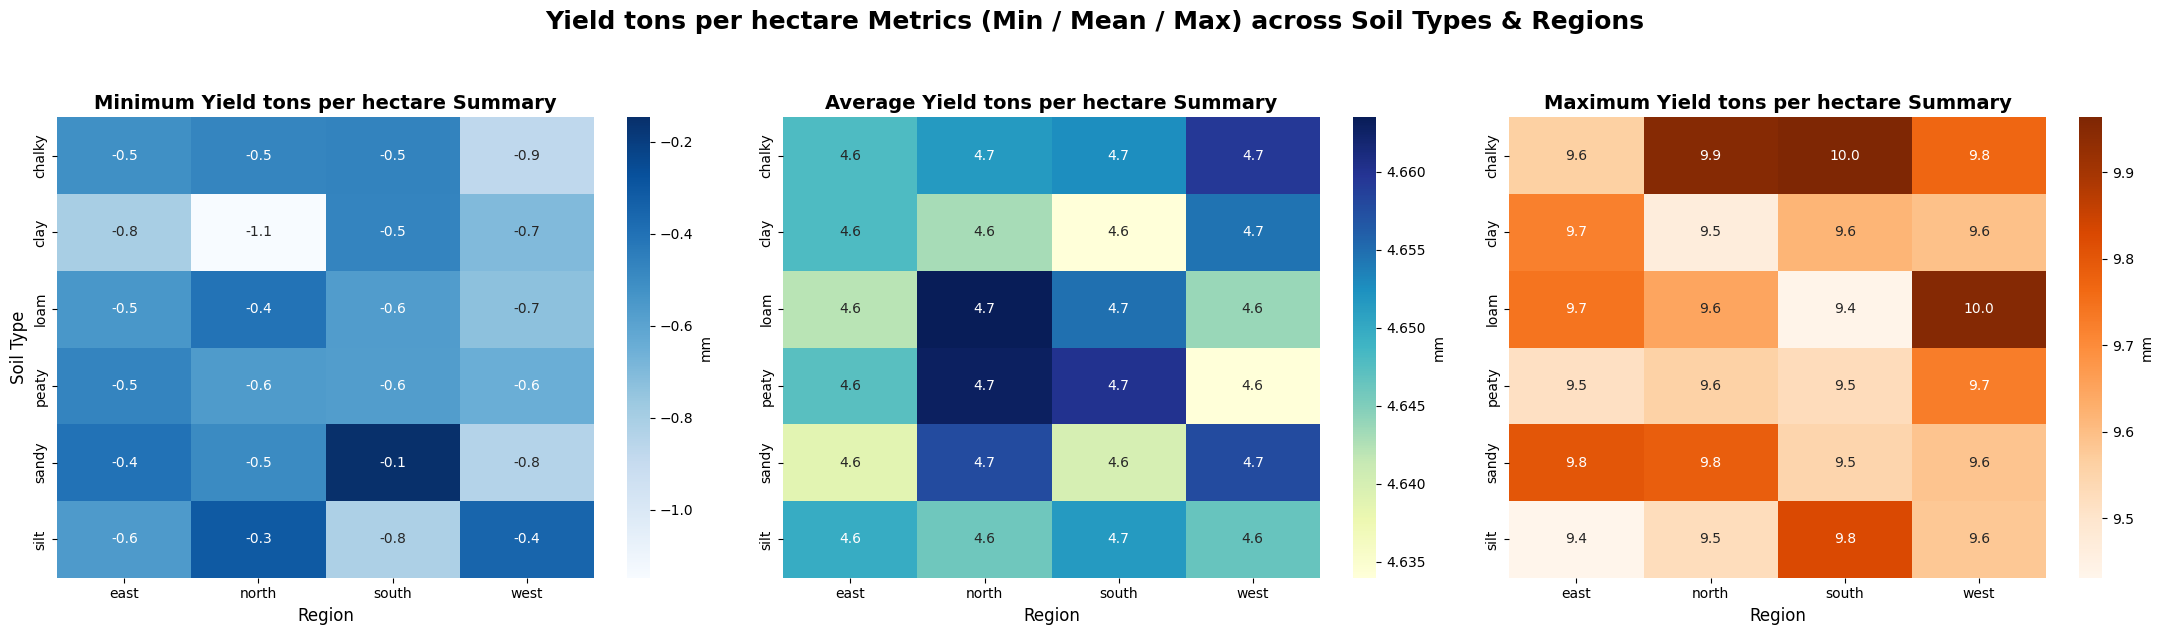

In [13]:
#=========================================== Filtering & Visualizing Dataset ============================================#
try:
    Yield_tons_per_hectare_avg_summary = crop_df.pivot_table(index='Soil_Type', columns='Region', values='Yield_tons_per_hectare', aggfunc='mean', margins=True)
    Yield_tons_per_hectare_min_summary = crop_df.pivot_table(index='Soil_Type', columns='Region', values='Yield_tons_per_hectare', aggfunc='min', margins=True)
    Yield_tons_per_hectare_max_summary = crop_df.pivot_table(index='Soil_Type', columns='Region', values='Yield_tons_per_hectare', aggfunc='max', margins=True)

    print("#================= Average Yield tons per hectare =================#")
    display(Yield_tons_per_hectare_avg_summary)
    print("\n#================= Minimum Yield tons per hectare =================#")
    display(Yield_tons_per_hectare_min_summary)
    print("\n#================= Maximum Yield tons per hectare =================#")
    display(Yield_tons_per_hectare_max_summary)

except Exception as e:
    print(f"Data generation error: {e}")

try:

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.heatmap(data=Yield_tons_per_hectare_min_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="Blues", ax=axes[0], cbar_kws={'label': 'mm'})
    axes[0].set_title("Minimum Yield tons per hectare Summary", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Region", fontsize=12)
    axes[0].set_ylabel("Soil Type", fontsize=12)

    sns.heatmap(data=Yield_tons_per_hectare_avg_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1], cbar_kws={'label': 'mm'})
    axes[1].set_title("Average Yield tons per hectare Summary", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Region", fontsize=12)
    axes[1].set_ylabel("") 
    

    sns.heatmap(data=Yield_tons_per_hectare_max_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="Oranges", ax=axes[2], cbar_kws={'label': 'mm'})
    axes[2].set_title("Maximum Yield tons per hectare Summary", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Region", fontsize=12)
    axes[2].set_ylabel("") 
    
    plt.suptitle("Yield tons per hectare Metrics (Min / Mean / Max) across Soil Types & Regions", fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig("Yield tons per hectare.png")
    plt.show()

except Exception as e:
    print(f"Plotting error: {e}")


#================= Average Yield tons per hectare =================#


Crop,barley,cotton,maize,rice,soybean,wheat,All
Soil_Type,,,,,,,
chalky,4.649948,4.663595,4.653498,4.640907,4.657995,4.651330,4.652895
clay,4.651793,4.645118,4.630174,4.646297,4.651116,4.644797,4.644891
loam,4.643126,4.633848,4.666891,4.651742,4.639517,4.671253,4.651056
peaty,4.650058,4.647561,4.635270,4.657866,4.661625,4.654183,4.651063
sandy,4.658929,4.652088,4.632811,4.654259,4.656205,4.636889,4.648511
silt,4.630665,4.662891,4.629473,4.653537,4.655866,4.658146,4.648414
All,4.647412,4.650841,4.641387,4.650760,4.653712,4.652740,4.649472



#================= Minimum Yield tons per hectare =================#


Crop,barley,cotton,maize,rice,soybean,wheat,All
Soil_Type,,,,,,,
chalky,-0.475287,-0.416235,-0.875193,-0.199079,-0.466695,-0.516340,-0.875193
clay,-0.471038,-0.507013,-0.699819,-0.253482,-0.434482,-1.147613,-1.147613
loam,-0.568767,-0.543567,-0.405764,-0.293918,-0.424637,-0.731541,-0.731541
peaty,-0.645920,-0.040815,-0.320319,-0.468290,-0.573014,-0.473565,-0.645920
sandy,-0.235296,-0.288273,-0.349601,-0.332519,-0.080500,-0.841617,-0.841617
silt,-0.818945,-0.590388,-0.559459,-0.154611,-0.595955,-0.262538,-0.818945
All,-0.818945,-0.590388,-0.875193,-0.468290,-0.595955,-1.147613,-1.147613



#================= Maximum Yield tons per hectare =================#


Crop,barley,cotton,maize,rice,soybean,wheat,All
Soil_Type,,,,,,,
chalky,9.949207,9.612279,9.525494,9.963372,9.677596,9.651654,9.963372
clay,9.595395,9.541572,9.653938,9.721110,9.462212,9.590294,9.721110
loam,9.744646,9.647672,9.952983,9.448676,9.499050,9.668197,9.952983
peaty,9.560555,9.471704,9.559016,9.527448,9.537442,9.727004,9.727004
sandy,9.525572,9.786272,9.503603,9.560674,9.548654,9.802534,9.802534
silt,9.580166,9.431513,9.826285,9.455356,9.559802,9.526382,9.826285
All,9.949207,9.786272,9.952983,9.963372,9.677596,9.802534,9.963372


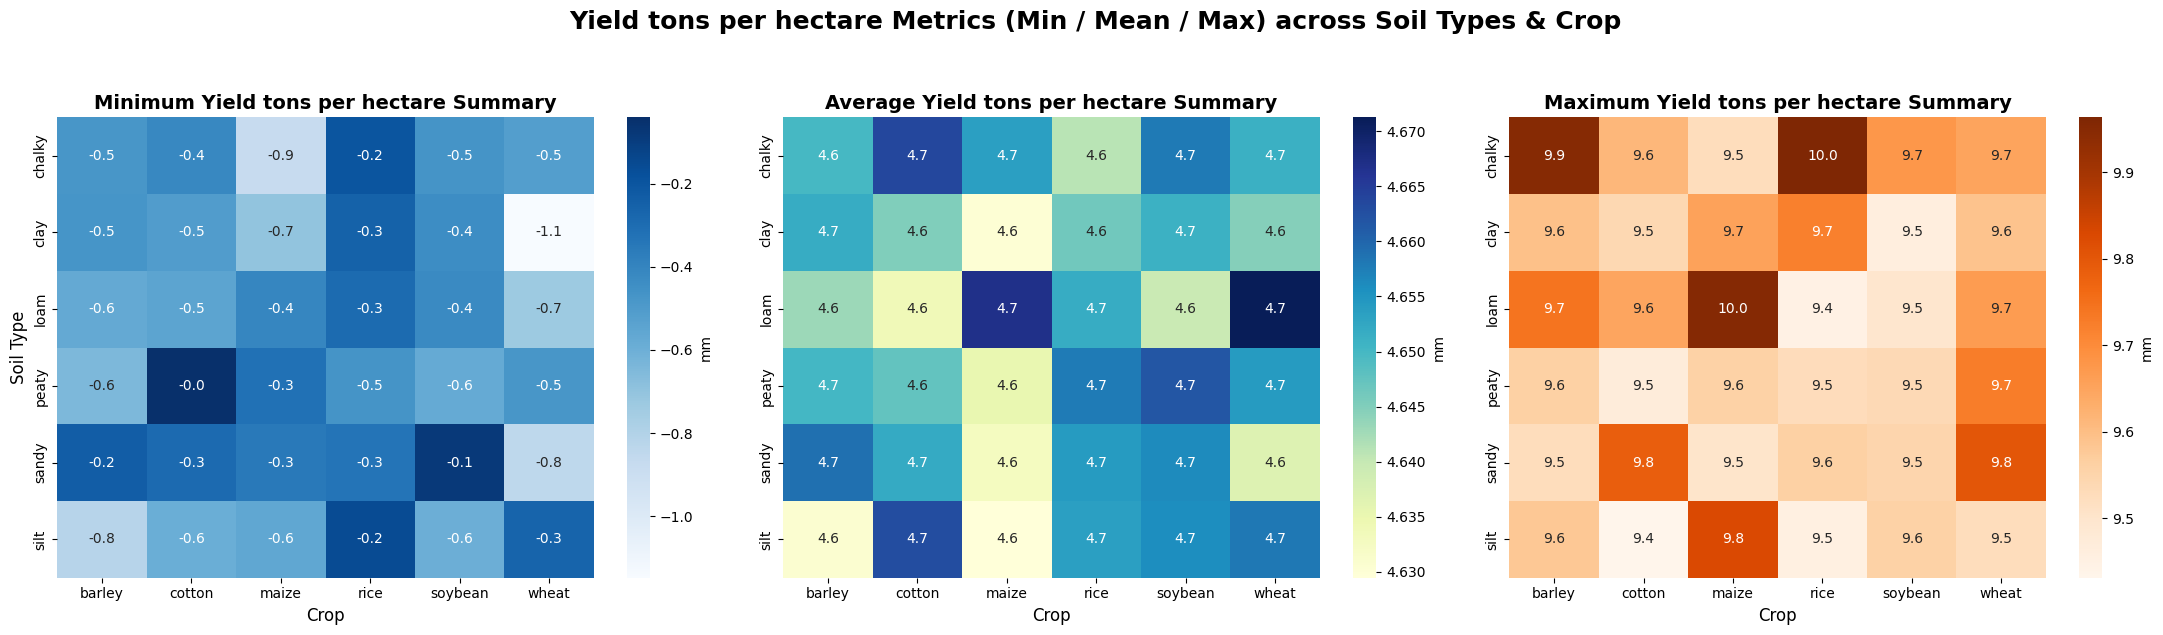

In [14]:
#=========================================== Filtering & Visualizing Dataset ============================================#
try:
    Yield_tons_per_hectare_avg_summary = crop_df.pivot_table(index='Soil_Type', columns='Crop', values='Yield_tons_per_hectare', aggfunc='mean', margins=True)
    Yield_tons_per_hectare_min_summary = crop_df.pivot_table(index='Soil_Type', columns='Crop', values='Yield_tons_per_hectare', aggfunc='min', margins=True)
    Yield_tons_per_hectare_max_summary = crop_df.pivot_table(index='Soil_Type', columns='Crop', values='Yield_tons_per_hectare', aggfunc='max', margins=True)

    print("#================= Average Yield tons per hectare =================#")
    display(Yield_tons_per_hectare_avg_summary)
    print("\n#================= Minimum Yield tons per hectare =================#")
    display(Yield_tons_per_hectare_min_summary)
    print("\n#================= Maximum Yield tons per hectare =================#")
    display(Yield_tons_per_hectare_max_summary)

except Exception as e:
    print(f"Data generation error: {e}")

try:

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.heatmap(data=Yield_tons_per_hectare_min_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="Blues", ax=axes[0], cbar_kws={'label': 'mm'})
    axes[0].set_title("Minimum Yield tons per hectare Summary", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Crop", fontsize=12)
    axes[0].set_ylabel("Soil Type", fontsize=12)

    sns.heatmap(data=Yield_tons_per_hectare_avg_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1], cbar_kws={'label': 'mm'})
    axes[1].set_title("Average Yield tons per hectare Summary", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Crop", fontsize=12)
    axes[1].set_ylabel("") 
    

    sns.heatmap(data=Yield_tons_per_hectare_max_summary.iloc[:-1, :-1], annot=True, fmt=".1f", cmap="Oranges", ax=axes[2], cbar_kws={'label': 'mm'})
    axes[2].set_title("Maximum Yield tons per hectare Summary", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Crop", fontsize=12)
    axes[2].set_ylabel("") 
    
    plt.suptitle("Yield tons per hectare Metrics (Min / Mean / Max) across Soil Types & Crop", fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig("Yield tons per hectare.png")
    plt.show()

except Exception as e:
    print(f"Plotting error: {e}")


In [15]:
#=========================================== Automated EDA ============================================#
try:
    report = ProfileReport(crop_df,explorative = True)
    report.to_file(output_file = 'crop_yield_EDA.html')
    print("✅EDA report generate complete")
except Exception as e:
    print(f"Error: {e}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:04<00:00,  2.08it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅EDA report generate complete


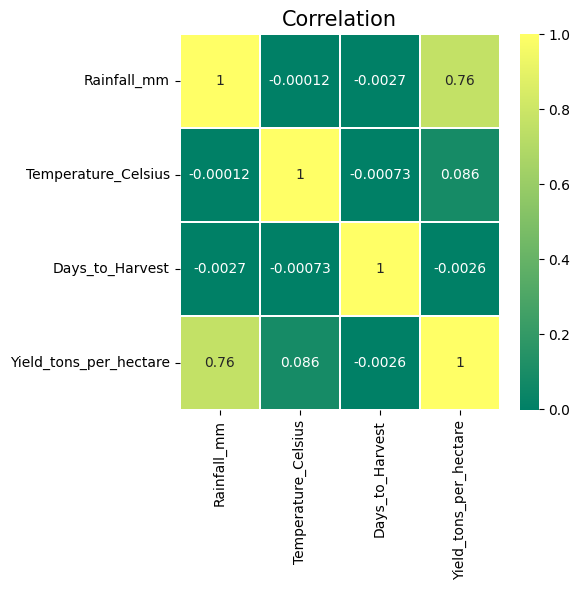

In [16]:
#============================================== Correlation ==============================================#
try:
    correlation = crop_df.select_dtypes(include = ['number']).corr()
    plt.figure(figsize = (6,6))
    plt.title("Correlation",fontsize = 15)
    sns.heatmap(correlation,annot = True,cmap = 'summer',linewidth = 0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error: {e}")


In [17]:
numeric_features = ['Rainfall_mm','Temperature_Celsius','Days_to_Harvest']
categorical_features = ['Region','Soil_Type','Crop','Fertilizer_Used','Irrigation_Used','Weather_Condition']
X = df[numeric_features + categorical_features]
y = df['Yield_tons_per_hectare']

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [19]:
preprocessing_data = ColumnTransformer(transformers=[
    ('numeric_features',StandardScaler(),numeric_features),
    ('categorical_features',OneHotEncoder(handle_unknown = 'ignore'),categorical_features)
],remainder = 'passthrough')

In [20]:
models = {
    'LinearRegression': LinearRegression(n_jobs=-1),
    'Ridge': Ridge(alpha=1.0),
    'HistGradientBoostingRegressor': HistGradientBoostingRegressor(
        max_iter=100,    
        max_depth=10,      
        random_state=42
    ),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=100,
        max_depth=10,         
        n_jobs=-1,          
        random_state=42
    ),
    'XGBRegressor': XGBRegressor(
        n_estimators=100,
        max_depth=6,      
        tree_method='hist',  
        n_jobs=-1,     
        random_state=42
    )
}

for name, model in models.items():
    if name in ['LinearRegression', 'Ridge']:
        pipeline = Pipeline(steps=[
            ('preprocessing_data', preprocessing_data),
            ('features_selection', SelectKBest(score_func=f_regression, k=29)),
            (name, model)
        ])
    else:
        pipeline = Pipeline(steps=[
            ('preprocessing_data', preprocessing_data),
            (name, model)
        ])
    
    try:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        print(f'\n#======================= {name} =======================#')
        print(f'MAE:  {mean_absolute_error(y_test, y_pred):.4f}')
        print(f'MSE:  {mean_squared_error(y_test, y_pred):.4f}')
        print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
        print(f'R2:   {r2_score(y_test, y_pred):.4f}')
        print(f"Training Score: {pipeline.score(X_train,y_train)}")
    except Exception as e:
        print(f"\nError training {name}: {e}")



#======================= LinearRegression =======================#
MAE:  0.3990
MSE:  0.2498
RMSE: 0.4998
R2:   0.9132
Training Score: 0.912940588572526

#======================= Ridge =======================#
MAE:  0.3990
MSE:  0.2498
RMSE: 0.4998
R2:   0.9132
Training Score: 0.912940588569592

#======================= HistGradientBoostingRegressor =======================#
MAE:  0.3994
MSE:  0.2504
RMSE: 0.5004
R2:   0.9130
Training Score: 0.913206650086556

#======================= RandomForestRegressor =======================#
MAE:  0.3997
MSE:  0.2507
RMSE: 0.5007
R2:   0.9128
Training Score: 0.9141216739880318

#======================= XGBRegressor =======================#
MAE:  0.4004
MSE:  0.2515
RMSE: 0.5015
R2:   0.9126
Training Score: 0.9142606161938369


In [22]:
#============================================ Hyper Tunning ============================================#
from scipy.stats import uniform
tune_pipeline = Pipeline(steps=[
    ('preprocessing_data', preprocessing_data),
    ('features_selection', SelectKBest(score_func=f_regression, k=26)),
    ('Ridge', Ridge(random_state=42))
])
param_distributions = {
    'Ridge__alpha': uniform(0.001, 100.0)
}
random_search = RandomizedSearchCV(
    estimator=tune_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,              
    scoring='r2',       
    n_jobs=-1,          
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)
print("\n#======================= RandomizedSearchCV Results =======================#")
print(f"Best Alpha Value: {random_search.best_params_['Ridge__alpha']:.4f}")
print(f"Best Cross-Validation R2 Score: {random_search.best_score_:.4f}")
best_model_random = random_search.best_estimator_
y_pred_tuned = best_model_random.predict(X_test)
print(f"Tuned Test R2 Score: {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Test MAE: {mean_absolute_error(y_test, y_pred_tuned):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

#======================= RandomizedSearchCV Results =======================#
Best Alpha Value: 5.8094
Best Cross-Validation R2 Score: 0.9129
Tuned Test R2 Score: 0.9132
Tuned Test MAE: 0.3990


In [23]:
#=========================================== Cross Validation ===========================================#
try:
    score_mse = cross_val_score(best_model_random,X,y,cv = 5,scoring = 'neg_mean_squared_error')
    score_mae = cross_val_score(best_model_random,X,y,cv = 5,scoring = 'neg_mean_absolute_error')
    score_r2 = cross_val_score(best_model_random,X,y,cv = 5,scoring = 'r2')
    print(f'MSE: {-score_mse}')
    print(f"MAE: {-score_mae}")
    print(f'R2: {score_r2}')
except Exception as e:
    print(f"Error: {e}")

MSE: [0.24942793 0.25086123 0.25101611 0.2504785  0.2497552 ]
MAE: [0.39839357 0.3996508  0.40020009 0.39915868 0.39872005]
R2: [0.91324987 0.91271599 0.91305518 0.91287258 0.91299993]


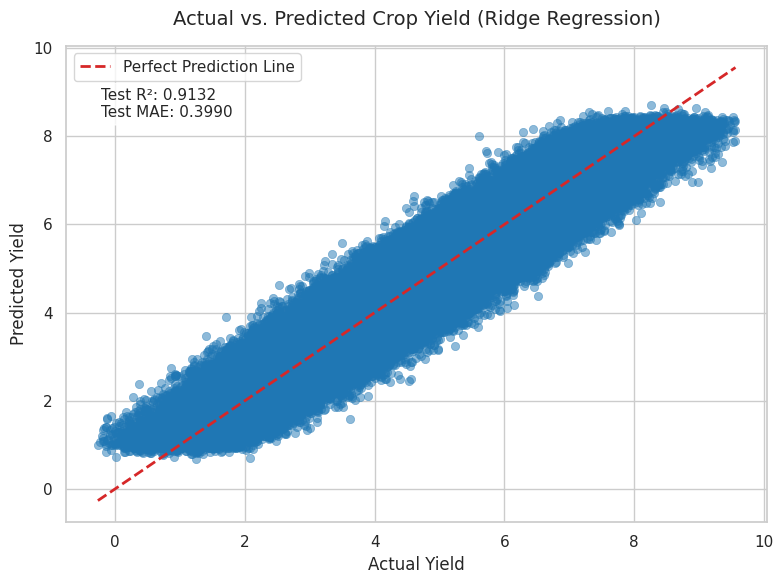

In [24]:
#=========================================== Actual Vs Predicted ===========================================#
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color="#1f77b4", edgecolor=None)
perfect_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_line, perfect_line, color="#d62728", linestyle="--", linewidth=2, label="Perfect Prediction Line")
plt.title("Actual vs. Predicted Crop Yield (Ridge Regression)", fontsize=14, pad=15)
plt.xlabel("Actual Yield", fontsize=12)
plt.ylabel("Predicted Yield", fontsize=12)
plt.legend(loc="upper left")
metrics_text = f"Test R²: 0.9132\nTest MAE: 0.3990"
plt.gca().text(0.05, 0.85, metrics_text, transform=plt.gca().transAxes, 
            fontsize=11, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.savefig('actual vs predicted.png')
plt.show()


In [25]:
# Save The Model
import joblib
joblib.dump(best_model_random,'best_model_yield_prediction.pkl')
print("✅Model Saved Complete")

✅Model Saved Complete


In [26]:
#================================================== Prediction ==================================================#
pipeline = joblib.load('best_model_yield_prediction.pkl')
print("✅ Full ML Pipeline Loaded Successfully!")

raw_input = {
    "Rainfall_mm": [322.622100],
    "Temperature_Celsius": [19.038621],
    "Days_to_Harvest": [95],
    "Region": ["west"],
    "Soil_Type": ["loam"],
    "Crop": ["rice"],
    "Fertilizer_Used": ['false'],  
    "Irrigation_Used": ['false'], 
    "Weather_Condition": ["cloudy"],
    "Temperature_category": ["cold"]
}


df_new = pd.DataFrame(raw_input)


prediction = pipeline.predict(df_new)

final_yield = np.clip(prediction[0], 0, None)
print(f"\nPredicted Crop Yield: {final_yield:.4f}")


✅ Full ML Pipeline Loaded Successfully!

Predicted Crop Yield: 1.9957
